In [1]:
import os
os.chdir("..")

In [2]:
from src.distances.hamming import compute_hamming_distance, compute_hamming_distance_matrix
from src.descriptors.keypoints.dog import detect_dog_keypoints_from_array
from src.descriptors.keypoints.harris import detect_harris_keypoints_from_array
from src.descriptors.sift import compute_sift_descriptor_from_array
from src.visualization.plots import draw_keypoints, draw_matches
from src.data.extract import read_image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Testing implementation of Hamming distance

In [3]:
# Example 1: two identical binary descriptors
a = np.array([1, 0, 1, 1, 0])
b = np.array([1, 0, 1, 1, 0])
print("Distance (identical):", compute_hamming_distance(a, b))
# Expected → 0 (no differing bits)

# Example 2: one bit different
a = np.array([1, 0, 1, 1, 0])
b = np.array([1, 0, 1, 0, 0])
print("Distance (one bit different):", compute_hamming_distance(a, b))
# Expected → 1

# Example 3: several bits different
a = np.array([1, 0, 1, 1, 0])
b = np.array([0, 1, 1, 0, 1])
print("Distance (several bits different):", compute_hamming_distance(a, b))
# Expected → 4


Distance (identical): 0
Distance (one bit different): 1
Distance (several bits different): 4


In [4]:
# Two binary descriptors for the query image (N=2, D=5 bits each)
A = np.array([
    [1, 0, 1, 1, 0],
    [0, 1, 0, 0, 1]
])

# Three binary descriptors for the museum image (M=3, D=5 bits each)
B = np.array([
    [1, 0, 1, 1, 0],   # identical to A[0]
    [0, 1, 1, 0, 0],   # partially similar
    [1, 1, 0, 1, 1]    # quite different
])

D = compute_hamming_distance_matrix(A, B)
print("Hamming distance matrix (N x M):\n", D)


Hamming distance matrix (N x M):
 [[0 3 3]
 [5 2 2]]


# Finding tentative matches

In [3]:
database_folder = "data/raw/BBDD"
data_folder = "data/raw/qsd1_w4"

img_query_path = f"{data_folder}/00001.jpg"
museum_paths = [
    f"{database_folder}/bbdd_00000.jpg",
    f"{database_folder}/bbdd_00018.jpg",
    f"{database_folder}/bbdd_00150.jpg",   # correct match
    f"{database_folder}/bbdd_00135.jpg"
]

img_query = read_image(img_query_path)
museum_imgs = [read_image(p) for p in museum_paths]

## DoG + SIFT


Query image → 2709 keypoints, descriptor shape: (2709, 128)


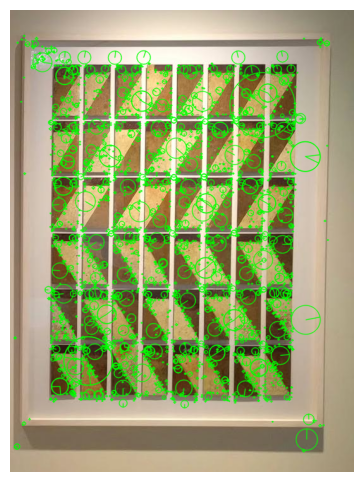

In [5]:
# Query image: detect DoG keypoints and compute SIFT descriptors
kps_q, desc_q = compute_sift_descriptor_from_array(
    img_query,
    keypoint_detector=detect_dog_keypoints_from_array,
    aggregation='none'  # keep all descriptors, not mean
)
print(f"Query image → {len(kps_q)} keypoints, descriptor shape: {desc_q.shape}")

draw_keypoints(
    img_query,        # your image (BGR)
    kps_q,            # list of cv2.KeyPoint objects
    color=(0, 255, 0),
    draw_rich=True   # show circles + orientation
)

Image 0: 5731 keypoints detected


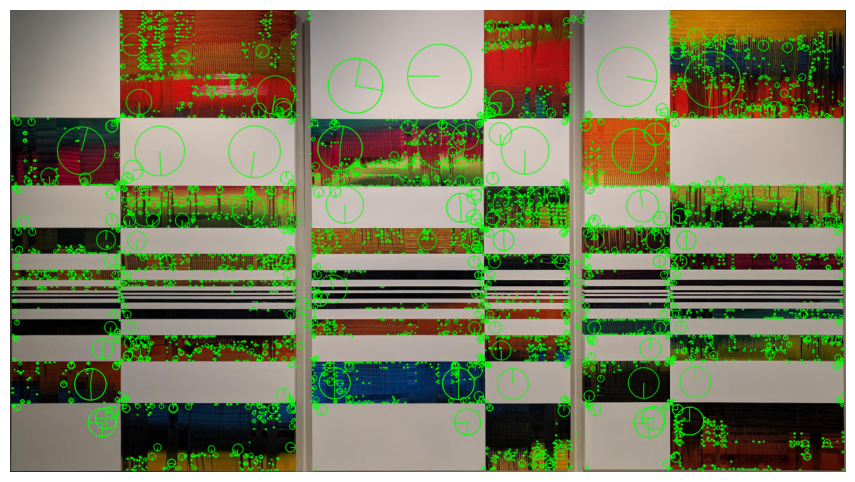

Image 1: 3519 keypoints detected


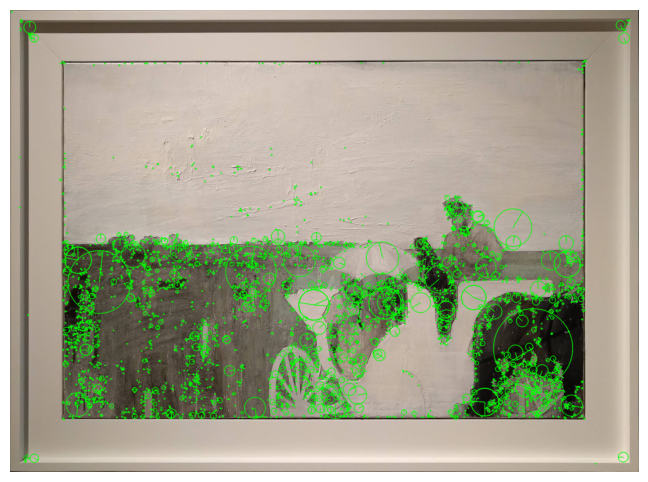

Image 2: 6639 keypoints detected


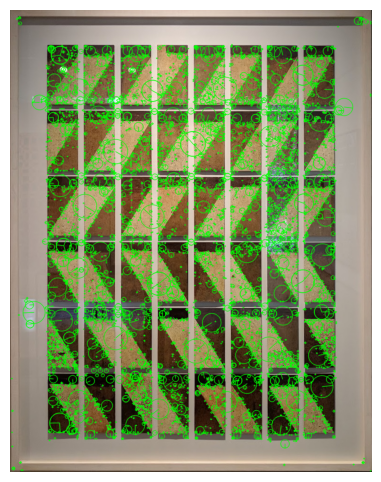

Image 3: 91492 keypoints detected


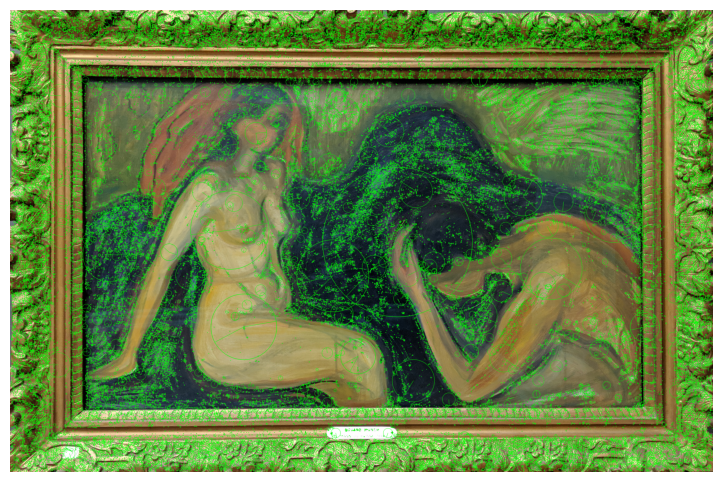

In [5]:
museum_kps = []
museum_desc = []

for i, img_m in enumerate(museum_imgs):
    kps_m, desc_m = compute_sift_descriptor_from_array(
        img_m,
        keypoint_detector=detect_dog_keypoints_from_array,
        aggregation='none'
    )

    museum_kps.append(kps_m)
    museum_desc.append(desc_m)

    print(f"Image {i}: {len(kps_m)} keypoints detected")
    draw_keypoints(
        img_m,
        kps_m,
        color=(0, 255, 0),
        draw_rich=True
    )

In [6]:
# Initialize matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
ratio_thresh = 0.75     # stricter ratio for fewer false matches
ransac_thresh = 10.0     # pixel reprojection threshold

results = []  # per-image stats
match_data = []  # matches for visualization

for i, desc_m in enumerate(museum_desc):
    if desc_q is None or desc_m is None or len(desc_m) == 0:
        results.append((i, 0, 0))
        match_data.append({
            "index": i,
            "good_matches": [],
            "inlier_matches": []
        })
        continue

    # Tentative matches 
    matches_knn = bf.knnMatch(desc_q, desc_m, k=2)
    good_matches = [m for m, n in matches_knn if m.distance < ratio_thresh * n.distance]
    num_tentative = len(good_matches)

    if num_tentative < 4:
        results.append((i, num_tentative, 0))
        match_data.append({
            "index": i,
            "good_matches": good_matches,
            "inlier_matches": []
        })
        continue

    # Verify matches using geometric consistency (RANSAC)
    src_pts = np.float32([kps_q[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([museum_kps[i][m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    matchesMask = mask.ravel().tolist() if mask is not None else []
    inlier_matches = [m for j, m in enumerate(good_matches) if mask is not None and matchesMask[j]]
    num_inliers = len(inlier_matches)

    results.append((i, num_tentative, num_inliers))

    match_data.append({
        "index": i,
        "good_matches": good_matches,
        "inlier_matches": inlier_matches
    })

    print(f"{museum_paths[i]} → tentative={num_tentative}, verified={num_inliers}")


data/raw/BBDD/bbdd_00000.jpg → tentative=56, verified=9
data/raw/BBDD/bbdd_00018.jpg → tentative=60, verified=14
data/raw/BBDD/bbdd_00150.jpg → tentative=364, verified=248
data/raw/BBDD/bbdd_00135.jpg → tentative=31, verified=6


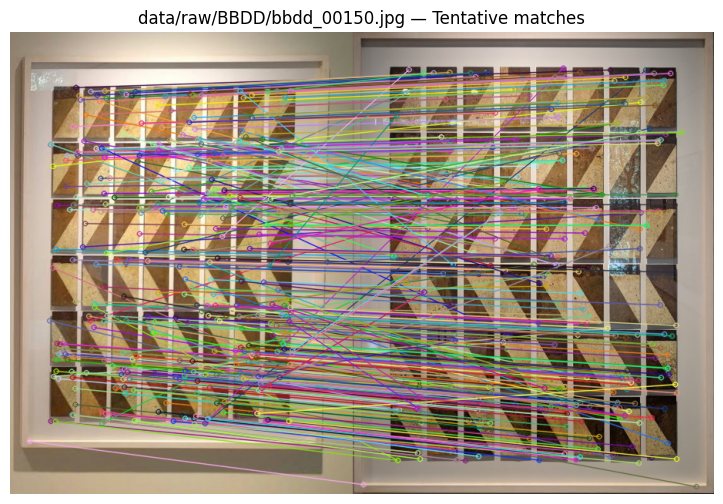

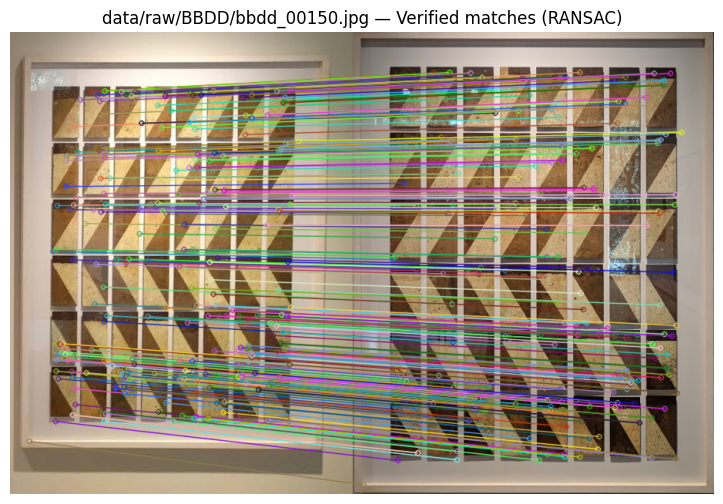

array([[[109, 125, 142],
        [109, 125, 142],
        [109, 125, 141],
        ...,
        [ 90, 102, 117],
        [ 89,  99, 109],
        [ 29,  31,  37]],

       [[109, 125, 142],
        [109, 125, 142],
        [109, 125, 141],
        ...,
        [ 89, 102, 117],
        [ 88,  98, 108],
        [ 29,  32,  38]],

       [[109, 125, 142],
        [109, 125, 142],
        [109, 125, 141],
        ...,
        [ 87,  99, 114],
        [ 89,  98, 110],
        [ 31,  37,  43]],

       ...,

       [[132, 160, 177],
        [132, 160, 177],
        [132, 161, 177],
        ...,
        [108, 125, 142],
        [107, 125, 140],
        [ 94, 112, 125]],

       [[132, 160, 177],
        [132, 160, 177],
        [133, 160, 177],
        ...,
        [112, 127, 142],
        [109, 125, 138],
        [ 72,  88, 100]],

       [[132, 160, 177],
        [132, 160, 177],
        [132, 160, 178],
        ...,
        [ 20,  24,  29],
        [ 21,  24,  29],
        [ 17,  20,  25]]

In [ ]:
i = 2  
img_m = museum_imgs[i]

# Tentative matches (before RANSAC)
draw_matches(
    img_query, kps_q,
    img_m, museum_kps[i],
    match_data[i]["good_matches"],
    title=f"{museum_paths[i]} — Tentative matches",
    resize=True   
)

# Verified matches (after RANSAC)
draw_matches(
    img_query, kps_q,
    img_m, museum_kps[i],
    match_data[i]["inlier_matches"],
    title=f"{museum_paths[i]} — Verified matches (RANSAC)",
    resize=True   
)
